# Import Libralies

In [47]:
# Math thingy
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# K-mean Algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Read the data file

In [48]:
def read_file(filepath):
    """reads the data file and shows as a dataframe."""
    df = pd.read_csv(filepath)
    return df

In [49]:
iris = 'iris.data'
df = read_file(iris)
df.sample(8)

,5.1,3.5,1.4,0.2,Iris-setosa
127,6.4,2.8,5.6,2.1,Iris-virginica
10,4.8,3.4,1.6,0.2,Iris-setosa
147,6.2,3.4,5.4,2.3,Iris-virginica
100,5.8,2.7,5.1,1.9,Iris-virginica
97,5.1,2.5,3.0,1.1,Iris-versicolor
49,7.0,3.2,4.7,1.4,Iris-versicolor
91,5.8,2.6,4.0,1.2,Iris-versicolor
130,7.9,3.8,6.4,2.0,Iris-virginica


# Get overview of the dataset

In [50]:
df.columns

Index(['5.1', '3.5', '1.4', '0.2', 'Iris-setosa'], dtype='object')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [52]:
df.shape

(149, 5)

In [53]:
df.isnull().sum().sum()

0

In [54]:
df.duplicated().sum()

3

In [55]:
def preprocessing(filepath):
    """cleans the dataset."""

    mapper = {
        0: "sepal_length",
        1: "sepal_width",
        2: "petal_length",
        3: "petal_width",
        4: "species"
    }

    # Read the data file and ADD header=None
    df = pd.read_csv(filepath, header=None)
    
    # drop duplicated rows 
    df = df.drop_duplicates()
    
    # Reset the index after dropping rows
    df = df.reset_index(drop=True) # drop=True prevents the old index from becoming a new column

    # Rename the columns
    df = df.rename(columns=mapper)

    return df

In [56]:
df_iris = preprocessing(iris)
df_iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
61,6.1,2.9,4.7,1.4,Iris-versicolor
114,6.5,3.0,5.5,1.8,Iris-virginica
45,4.6,3.2,1.4,0.2,Iris-setosa
19,5.1,3.8,1.5,0.3,Iris-setosa
0,5.1,3.5,1.4,0.2,Iris-setosa


# K-means Algorithm

## Data Preparation

In [57]:
# 1. Select only the numerical features for clustering
X = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# 2. Standardize the data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

## Iris Flower Segmentation

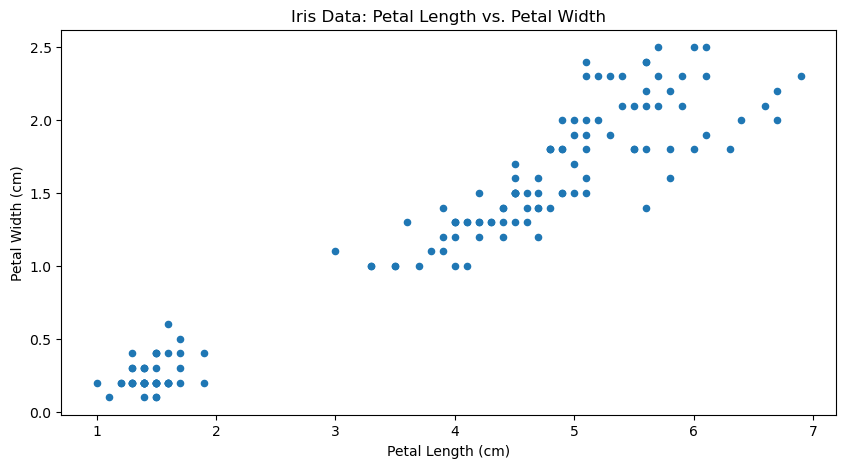

In [58]:
df_iris.plot(kind='scatter',
             x='petal_length',
             y='petal_width',
             figsize=(10,5))
plt.title('Iris Data: Petal Length vs. Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

## Find the optimum number of clusters using the Elbow method

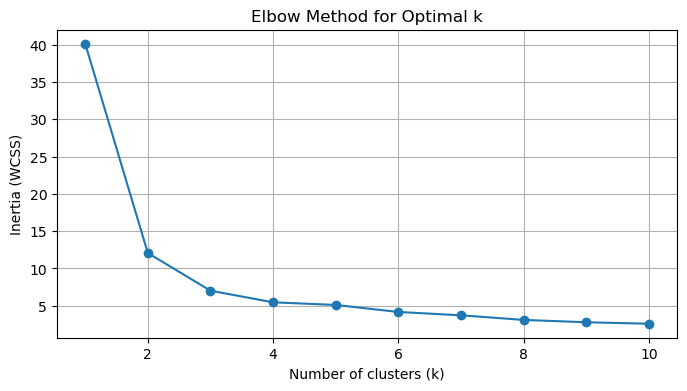

In [59]:
def optimise_k_means(data, max_k):
    """Identifies the optimal numbers of cluster."""
    
    # Corrected variable name: 'ks' instead of 'mean' for clarity
    ks = []
    inertias = []

    # Iterate from k=1 up to (but not including) max_k
    for k in range(1, max_k):
        # 1. K-means model creation and fitting
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(data)

        # 2. Append results (k, and the inertia)
        ks.append(k)
        inertias.append(kmeans.inertia_)
        
    # Generate the elbow plot
    fig = plt.subplots(figsize=(8, 4))
    plt.plot(ks, inertias, 'o-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia (WCSS)')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()


# We'll use max_k=11 to test k=1 through k=10
optimise_k_means(X_scaled, max_k=11)

## Fit the data

In [60]:
# 1. Initialize the model with the optimal k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')

# 2. Fit the model using the SCALED NUMERICAL DATA
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [61]:
# Get the cluster assignments (0, 1, or 2) for each data point
cluster_labels = kmeans.labels_

# Add the cluster labels back to your original, unscaled DataFrame
df_iris['Cluster'] = cluster_labels

# Now you can analyze the characteristics of each cluster in df_iris

## Prepare for the plot

In [62]:
# Now, select the columns you need for the plot
# We will use the original, unscaled measurements for plotting.
X_unscaled = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] 
y_cluster = df_iris['Cluster']

## Plot the result with centers of each cluster

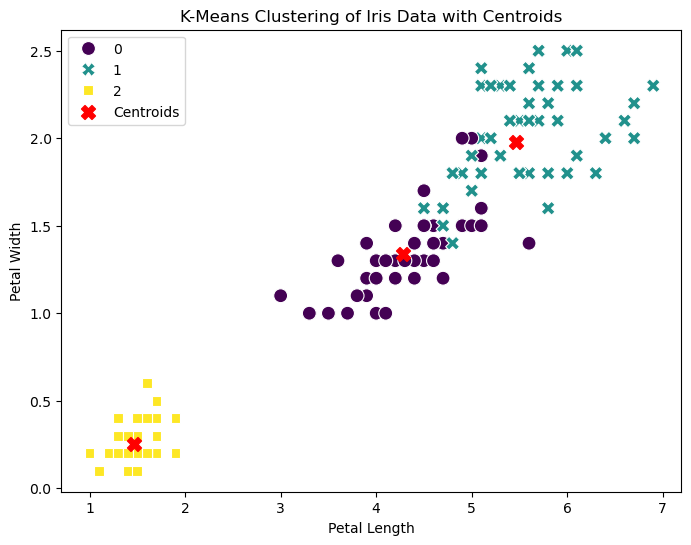

In [ ]:
# 1. Get the SCALED centroid coordinates
centroids_scaled = kmeans.cluster_centers_

# 2. Inverse Transform the centroids back to the original scale
# We need to reshape the scaled features (X_scaled) to get the original columns 
# so the inverse_transform works correctly for the features used in the plot (petal_length and petal_width)
centroids_unscaled = scaler.inverse_transform(centroids_scaled)

# 3. Convert the unscaled centroids back to a DataFrame for easier plotting
# We use the original column names
centroids_df = pd.DataFrame(centroids_unscaled, columns=X.columns)


# Plotting Code with Centroids
plt.figure(figsize=(8, 6))

# Scatter Plot for Data Points
sns.scatterplot(
    x=df_iris['petal_length'], 
    y=df_iris['petal_width'], 
    hue=df_iris['Cluster'], 
    palette='viridis', 
    style=df_iris['Cluster'],
    s=100, 
    legend='full'
)

# Add Centroids
plt.scatter(
    x=centroids_df['petal_length'],  # Petal Length for centroids
    y=centroids_df['petal_width'],   # Petal Width for centroids
    marker='X',                      # Use an 'X' marker for visibility
    s=100,                           # Make the markers large
    color='red',                     # Use a distinct color
    label='Centroids'
)

plt.title('K-Means Clustering of Iris Data with Centroids')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

## Interpretation

In [64]:
# FIX: Use numeric_only=True to exclude the 'species' (object) column
cluster_analysis = df_iris.groupby('Cluster').mean(numeric_only=True)

print(cluster_analysis)

         sepal_length  sepal_width  petal_length  petal_width
Cluster                                                      
0            5.782979     2.663830      4.280851     1.338298
1            6.703846     3.063462      5.467308     1.976923
2            5.010417     3.431250      1.462500     0.250000


In [65]:
# Assuming you still have the original, unscaled df_iris with the 'species' column:
# You need to map the species strings to integers (0, 1, 2) for comparison
species_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y_true = df_iris['species'].map(species_mapping) # True labels as numbers
y_pred = df_iris['Cluster']                    # Predicted K-means cluster labels

# Calculate the Adjusted Rand Index
ari_score = adjusted_rand_score(y_true, y_pred)

print(f"Adjusted Rand Index (ARI) Score: {ari_score:.4f}")
print("\nConfusion Matrix (True vs. Predicted Clusters):")
print(confusion_matrix(y_true, y_pred))

Adjusted Rand Index (ARI) Score: 0.7058

Confusion Matrix (True vs. Predicted Clusters):
[[ 0  0 48]
 [40 10  0]
 [ 7 42  0]]
